# Homework 2.1 — Group Fixed Effects Regression

**Question.** Run a regression that estimates the fixed effect of each group. Assume there is a
*single* linear coefficient shared by all the data, plus a fixed effect for each group.
Data: `homework_2.1.csv`. `G1`, `G2`, `G3` are the outcomes, `time` is the treatment.

**Model**

$$y_{g,t} \;=\; \alpha_g \;+\; \beta\, t \;+\; \varepsilon_{g,t}, \qquad g \in \{G1, G2, G3\}$$

- $\beta$ — one common slope on `time`, estimated from **all** the data pooled together.
- $\alpha_{G1}, \alpha_{G2}, \alpha_{G3}$ — the group fixed effects (group-specific intercepts).

To fit this, the wide data (one column per group) is reshaped into **long** form — one row per
(group, time) observation — and estimated by OLS with a full set of group dummies and **no
overall intercept**, so each dummy coefficient *is* that group's fixed effect $\alpha_g$.

## 1. Setup

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

try:
    import statsmodels.formula.api as smf
    HAS_SM = True
except ImportError:
    HAS_SM = False
    print("statsmodels not installed - the manual NumPy section below gives the same answers.")

pd.set_option("display.float_format", lambda v: f"{v:,.6f}")
CSV_PATH = "homework_2.1.csv"   # <-- change if the file lives somewhere else

## 2. Load and inspect the data

In [28]:
df = pd.read_csv(CSV_PATH)

print("shape:", df.shape)
print("\ndtypes:\n", df.dtypes, sep="")
print("\nmissing values per column:\n", df.isna().sum(), sep="")
df.head()

shape: (100, 4)

dtypes:
time      int64
G1      float64
G2      float64
G3      float64
dtype: object

missing values per column:
time    0
G1      0
G2      0
G3      0
dtype: int64


,time,G1,G2,G3
0,0,0.882026,1.441575,0.065409
1,1,0.210079,-0.163880,0.140310
2,2,0.509369,-0.115242,0.819830
3,3,1.150447,1.014698,0.607632
4,4,0.973779,-0.046562,0.610066


In [29]:
df.describe()

,time,G1,G2,G3
count,100.000000,100.000000,100.000000,100.000000
mean,49.500000,0.524904,1.036006,0.715384
std,29.011492,0.561614,0.552593,0.581227
min,0.000000,-1.076495,-0.163880,-0.508478
25%,24.750000,0.186046,0.621088,0.298386
50%,49.500000,0.464842,1.006778,0.643041
75%,74.250000,0.947191,1.427074,1.125461
max,99.000000,1.862935,2.561618,2.321958


## 3. Identify the treatment column and the outcome columns

`time` is stored as **whole numbers**; the three outcomes are **rational / decimal** values.
That is used here as an automatic check, so the script still picks the right columns even if
the headers are missing, misspelled, or in a different order.

In [30]:
def is_whole_number_column(s: pd.Series) -> bool:
    # True if every non-missing value in the column is an integer value.
    v = pd.to_numeric(s, errors="coerce").dropna()
    return len(v) > 0 and np.allclose(v.to_numpy(), np.round(v.to_numpy()))

whole_cols   = [c for c in df.columns if is_whole_number_column(df[c])]
decimal_cols = [c for c in df.columns if c not in whole_cols]

print("whole-number column(s):", whole_cols)
print("decimal column(s):     ", decimal_cols)

# Prefer a column literally named 'time'; otherwise fall back to the whole-number column.
TIME_COL = next((c for c in df.columns if c.strip().lower() == "time"), whole_cols[0])
OUTCOME_COLS = [c for c in df.columns if c != TIME_COL]

print(f"\ntreatment  -> {TIME_COL}")
print(f"outcomes   -> {OUTCOME_COLS}")

assert is_whole_number_column(df[TIME_COL]), "The treatment column should be whole numbers."
assert len(OUTCOME_COLS) >= 2, "Expected several outcome columns (G1, G2, G3)."

whole-number column(s): ['time']
decimal column(s):      ['G1', 'G2', 'G3']

treatment  -> time
outcomes   -> ['G1', 'G2', 'G3']


## 4. Reshape wide → long

Each row of the CSV holds three separate observations (one per group). Stacking them gives one
row per (group, time) pair, which is the shape the pooled regression needs.

In [31]:
long = (
    df.melt(id_vars=TIME_COL, value_vars=OUTCOME_COLS,
            var_name="group", value_name="y")
      .rename(columns={TIME_COL: "time"})
      .dropna(subset=["time", "y"])
      .astype({"time": float, "y": float})
      .sort_values(["group", "time"])
      .reset_index(drop=True)
)

GROUPS = sorted(long["group"].unique())
print(f"{len(long)} observations, {len(GROUPS)} groups: {GROUPS}")
print("observations per group:\n", long['group'].value_counts().sort_index(), sep="")
long.head()

300 observations, 3 groups: ['G1', 'G2', 'G3']
observations per group:
group
G1    100
G2    100
G3    100
Name: count, dtype: int64


,time,group,y
0,0.000000,G1,0.882026
1,1.000000,G1,0.210079
2,2.000000,G1,0.509369
3,3.000000,G1,1.150447
4,4.000000,G1,0.973779


## 5. Main regression — absolute fixed effects

Fitting `y ~ C(group) + time - 1` drops the overall intercept and keeps **all three** group
dummies, so each coefficient is read directly as that group's fixed effect $\alpha_g$, and the
single `time` coefficient is the common slope $\beta$.

In [32]:
if HAS_SM:
    fe_model = smf.ols("y ~ C(group) + time - 1", data=long).fit()
    print(fe_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.311
Model:                            OLS   Adj. R-squared:                  0.304
Method:                 Least Squares   F-statistic:                     44.55
Date:                Mon, 14 Sep 2026   Prob (F-statistic):           8.72e-24
Time:                        03:37:54   Log-Likelihood:                -216.89
No. Observations:                 300   AIC:                             441.8
Df Residuals:                     296   BIC:                             456.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
C(group)[G1]     0.0786      0.071      1.112   

In [33]:
if HAS_SM:
    results = pd.DataFrame({
        "coefficient": fe_model.params,
        "std_error":   fe_model.bse,
        "t_stat":      fe_model.tvalues,
        "p_value":     fe_model.pvalues,
        "ci_lower":    fe_model.conf_int()[0],
        "ci_upper":    fe_model.conf_int()[1],
    })
    display(results)

,coefficient,std_error,t_stat,p_value,ci_lower,ci_upper
C(group)[G1],0.078552,0.070633,1.112118,0.266990,-0.060454,0.217558
C(group)[G2],0.589654,0.070633,8.348174,0.000000,0.450648,0.728660
C(group)[G3],0.269032,0.070633,3.808882,0.000170,0.130026,0.408038
time,0.009017,0.001004,8.981913,0.000000,0.007041,0.010993


## 6. Same model, `G1` as the reference group

The identical fit, re-parameterised: the intercept is now $\alpha_{G1}$ and each remaining
coefficient is a *difference* from `G1`, i.e. $\alpha_g - \alpha_{G1}$. Useful when the question
of interest is whether the groups differ from one another. `time`, $R^2$, and the residuals are
unchanged — only the labelling of the intercepts moves.

In [34]:
if HAS_SM:
    rel_model = smf.ols("y ~ C(group) + time", data=long).fit()
    print(rel_model.summary().tables[1])
    print(f"\nR-squared identical to model above: "
          f"{np.isclose(rel_model.rsquared, fe_model.rsquared)}")

                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.0786      0.071      1.112      0.267      -0.060       0.218
C(group)[T.G2]     0.5111      0.071      7.200      0.000       0.371       0.651
C(group)[T.G3]     0.1905      0.071      2.683      0.008       0.051       0.330
time               0.0090      0.001      8.982      0.000       0.007       0.011

R-squared identical to model above: True


## 7. Manual estimation with NumPy (verification)

The same OLS problem built by hand, $\hat{b} = (X'X)^{-1}X'y$, with

$$X = [\,d_{G1}\;\; d_{G2}\;\; d_{G3}\;\; t\,]$$

where $d_g$ are 0/1 group dummies. This reproduces the numbers above and runs even without
statsmodels installed.

In [35]:
# Design matrix: one dummy per group, then the common time regressor. No intercept column.
D = np.column_stack([(long["group"] == g).to_numpy(float) for g in GROUPS])
t = long["time"].to_numpy(float)
X = np.column_stack([D, t])
y = long["y"].to_numpy(float)
names = [f"alpha[{g}]" for g in GROUPS] + ["beta[time]"]

n, k = X.shape
XtX_inv = np.linalg.inv(X.T @ X)
b = XtX_inv @ X.T @ y

resid = y - X @ b
rss = resid @ resid
tss = ((y - y.mean()) ** 2).sum()
sigma2 = rss / (n - k)

se = np.sqrt(np.diag(XtX_inv) * sigma2)
t_stat = b / se
p_val = 2 * stats.t.sf(np.abs(t_stat), df=n - k)
crit = stats.t.ppf(0.975, df=n - k)

manual = pd.DataFrame({
    "coefficient": b,
    "std_error":   se,
    "t_stat":      t_stat,
    "p_value":     p_val,
    "ci_lower":    b - crit * se,
    "ci_upper":    b + crit * se,
}, index=names)

print(f"n = {n}, parameters = {k}, residual df = {n - k}")
print(f"R^2 (uncentered model, vs. mean) = {1 - rss / tss:.6f}")
print(f"Residual std. error              = {np.sqrt(sigma2):.6f}\n")
manual

n = 300, parameters = 4, residual df = 296
R^2 (uncentered model, vs. mean) = 0.311047
Residual std. error              = 0.501940



,coefficient,std_error,t_stat,p_value,ci_lower,ci_upper
alpha[G1],0.078552,0.070633,1.112118,0.266990,-0.060454,0.217558
alpha[G2],0.589654,0.070633,8.348174,0.000000,0.450648,0.728660
alpha[G3],0.269032,0.070633,3.808882,0.000170,0.130026,0.408038
beta[time],0.009017,0.001004,8.981913,0.000000,0.007041,0.010993


In [36]:
# Cross-check the two approaches agree to numerical precision.
if HAS_SM:
    print("max abs difference in coefficients:",
          np.max(np.abs(np.sort(fe_model.params.to_numpy()) - np.sort(b))))

max abs difference in coefficients: 6.7584826624056404e-15


## 8. Plot: data and fitted lines

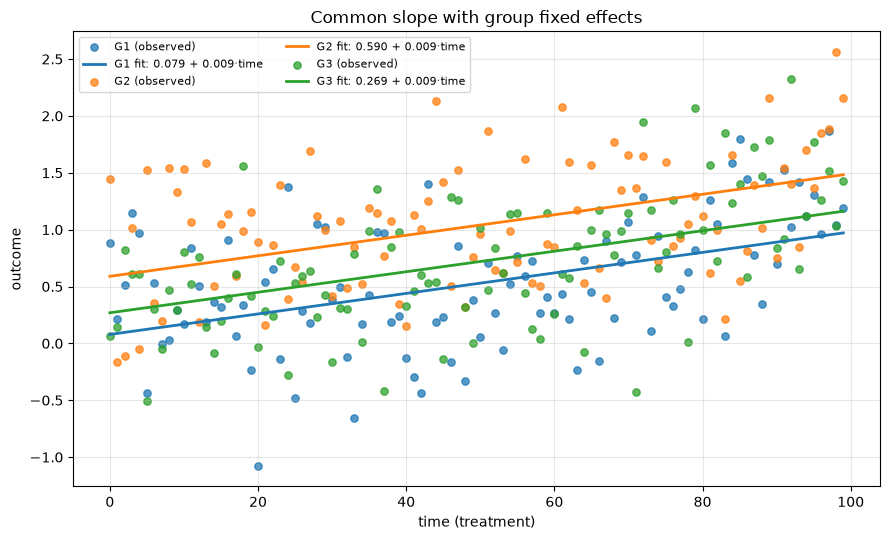

In [37]:
alpha = dict(zip(GROUPS, b[:len(GROUPS)]))
beta = b[-1]

fig, ax = plt.subplots(figsize=(9, 5.5))
grid = np.linspace(long["time"].min(), long["time"].max(), 100)

for g, color in zip(GROUPS, plt.rcParams["axes.prop_cycle"].by_key()["color"]):
    sub = long[long["group"] == g]
    ax.scatter(sub["time"], sub["y"], s=28, alpha=0.75, color=color, label=f"{g} (observed)")
    ax.plot(grid, alpha[g] + beta * grid, color=color, lw=2,
            label=f"{g} fit: {alpha[g]:.3f} + {beta:.3f}·time")

ax.set_xlabel("time (treatment)")
ax.set_ylabel("outcome")
ax.set_title("Common slope with group fixed effects")
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

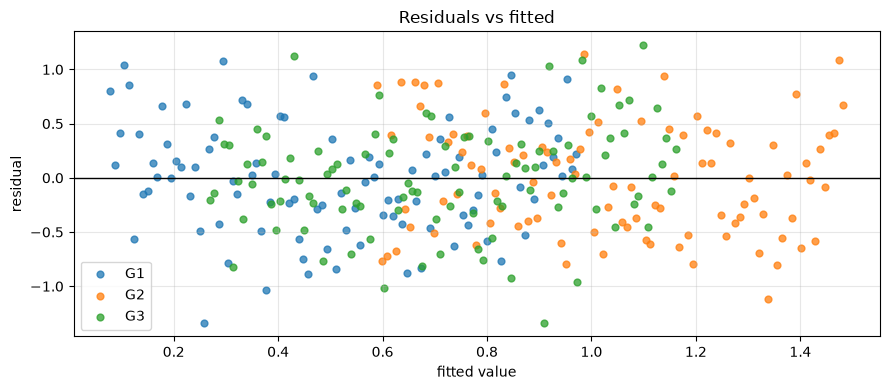

mean residual by group (should be ~0):
group
G1    0.000000
G2   -0.000000
G3   -0.000000
Name: resid, dtype: float64


In [38]:
# Residual check: fixed effects should leave no group-level mean residual.
long["fitted"] = X @ b
long["resid"] = long["y"] - long["fitted"]

fig, ax = plt.subplots(figsize=(9, 4))
for g in GROUPS:
    sub = long[long["group"] == g]
    ax.scatter(sub["fitted"], sub["resid"], s=24, alpha=0.75, label=g)
ax.axhline(0, color="black", lw=1)
ax.set_xlabel("fitted value")
ax.set_ylabel("residual")
ax.set_title("Residuals vs fitted")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("mean residual by group (should be ~0):")
print(long.groupby("group")["resid"].mean())

## 9. Answer

In [39]:
print("Estimated model:  y[g,t] = alpha[g] + beta * time + e[g,t]\n")
print(f"Common time coefficient (beta): {beta:.6f}"
      f"   (se {se[-1]:.6f}, t {t_stat[-1]:.3f}, p {p_val[-1]:.3g})\n")
print("Group fixed effects:")
for i, g in enumerate(GROUPS):
    print(f"  alpha[{g}] = {b[i]:10.6f}   (se {se[i]:.6f}, t {t_stat[i]:.3f}, p {p_val[i]:.3g})")

base = GROUPS[0]
print(f"\nDifferences relative to {base}:")
for g in GROUPS[1:]:
    print(f"  alpha[{g}] - alpha[{base}] = {alpha[g] - alpha[base]:.6f}")

Estimated model:  y[g,t] = alpha[g] + beta * time + e[g,t]

Common time coefficient (beta): 0.009017   (se 0.001004, t 8.982, p 3.19e-17)

Group fixed effects:
  alpha[G1] =   0.078552   (se 0.070633, t 1.112, p 0.267)
  alpha[G2] =   0.589654   (se 0.070633, t 8.348, p 2.69e-15)
  alpha[G3] =   0.269032   (se 0.070633, t 3.809, p 0.00017)

Differences relative to G1:
  alpha[G2] - alpha[G1] = 0.511102
  alpha[G3] - alpha[G1] = 0.190480


***

# Homework 2.2 - Bootstrap Simulation

**Task.** Given the data set `homework_2.2.csv`, build a bootstrap simulation to explore
different possibilities.

Variables: `X` is the binary treatment (0/1), `Y` and `Z` are continuous. `Y` is taken as the
outcome and `Z` as the confounder (Section 7 re-runs everything with the roles swapped, in case
the file uses the other convention).

**Questions answered here**

| # | Question | Where |
|---|---|---|
| 3 | Mean effect from the naive difference of means | Section 3 |
| 4 | Bootstrap variance of that naive effect | Section 4 |
| 5 | Skewness of the effect from a linear regression (with intercept) | Section 5 |

**Definitions used**

- Naive effect: $\hat{\tau}_{naive} = \bar{Y}_{X=1} - \bar{Y}_{X=0}$. This ignores the confounder,
  which is exactly why it is not the recommended estimator.
- Bootstrap: draw $B$ resamples of the *rows* with replacement, each the same size as the original
  data, recompute the effect in each one, and use the spread of those $B$ estimates.
- Regression effect: the coefficient on `X` in $Y = \beta_0 + \beta_1 X + \beta_2 Z + \varepsilon$.
- Skewness: `scipy.stats.skew` applied to the $B$ bootstrap regression estimates.

## 1. Setup

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

CSV_PATH = "homework_2.2.csv"   # <-- change if the file lives somewhere else
B = 10_000                      # number of bootstrap resamples
SEED = 42                       # fixed seed so the numbers are reproducible

rng = np.random.default_rng(SEED)
pd.set_option("display.float_format", lambda v: f"{v:,.6f}")

## 2. Load the data and identify the variables

In [64]:
df = pd.read_csv(CSV_PATH)

print("shape:", df.shape)
print("\nmissing values:\n", df.isna().sum(), sep="")
df.head()

shape: (10000, 3)

missing values:
X    0
Y    0
Z    0
dtype: int64


,X,Y,Z
0,0,1.182435,-0.725820
1,0,2.714474,0.563476
2,0,0.077612,-0.435632
3,0,-0.154449,-0.104553
4,0,22.298992,-2.321273


In [65]:
def is_binary(s: pd.Series) -> bool:
    # True if the column only takes the values 0 and 1
    v = pd.to_numeric(s, errors="coerce").dropna().unique()
    return set(np.round(v, 12)) <= {0.0, 1.0}

binary_cols  = [c for c in df.columns if is_binary(df[c])]
numeric_cols = [c for c in df.columns if c not in binary_cols]

print("binary column(s)     :", binary_cols)
print("continuous column(s) :", numeric_cols)

# Prefer the literal names X / Y / Z when they exist.
TREAT   = next((c for c in df.columns if c.strip().upper() == "X"), binary_cols[0])
OUTCOME = next((c for c in df.columns if c.strip().upper() == "Y"), numeric_cols[0])
CONFOUND = next((c for c in df.columns if c.strip().upper() == "Z"),
                [c for c in numeric_cols if c != OUTCOME][0])

print(f"\ntreatment  X -> {TREAT}")
print(f"outcome    Y -> {OUTCOME}")
print(f"confounder Z -> {CONFOUND}")

data = df[[TREAT, OUTCOME, CONFOUND]].dropna().reset_index(drop=True)
x = data[TREAT].to_numpy(float)
y = data[OUTCOME].to_numpy(float)
z = data[CONFOUND].to_numpy(float)
n = len(data)

print(f"\nn = {n}   treated = {int(x.sum())}   control = {int((1 - x).sum())}")
data.describe()

binary column(s)     : ['X']
continuous column(s) : ['Y', 'Z']

treatment  X -> X
outcome    Y -> Y
confounder Z -> Z

n = 10000   treated = 1972   control = 8028


,X,Y,Z
count,"10,000.000000","10,000.000000","10,000.000000"
mean,0.197200,5.498005,-0.000690
std,0.397905,7.307418,0.990785
min,0.000000,-0.200000,-3.694285
25%,0.000000,0.608725,-0.663618
50%,0.000000,3.080435,-0.010368
75%,0.000000,7.378477,0.669695
max,1.000000,71.935798,3.598310


In [66]:
# Quick look at the confounding: Z differs systematically between the two groups,
# so a raw difference in Y mixes the treatment effect with the effect of Z.
data.groupby(TREAT)[[OUTCOME, CONFOUND]].agg(["mean", "std", "count"])

Y                        Z               
      mean      std count      mean      std count
X                                                 
0 4.922040 7.250487  8028 -0.010159 0.994229  8028
1 7.842757 7.067458  1972  0.037857 0.975940  1972

## 3. Question 3 - naive difference of means

$$\hat{\tau}_{naive} = \bar{Y}_{X=1} - \bar{Y}_{X=0}$$

In [67]:
def naive_effect(x, y):
    # Difference in mean outcome between treated and untreated. Ignores the confounder.
    return y[x == 1].mean() - y[x == 0].mean()

tau_naive = naive_effect(x, y)

print(f"mean outcome, treated  (X=1): {y[x == 1].mean():.6f}")
print(f"mean outcome, control  (X=0): {y[x == 0].mean():.6f}")
print(f"\n>>> Q3  naive mean effect = {tau_naive:.6f}")

mean outcome, treated  (X=1): 7.842757
mean outcome, control  (X=0): 4.922040

>>> Q3  naive mean effect = 2.920717


## 4. Question 4 - bootstrap variance of the naive effect

Each replicate resamples the rows of the data set with replacement (keeping `X`, `Y`, `Z`
together on the same row), recomputes the naive difference of means, and stores it. The answer
is the variance of those `B` numbers.

In [68]:
boot_idx = rng.integers(0, n, size=(B, n))     # B resamples of n row indices, with replacement

boot_naive = np.empty(B)
for b in range(B):
    idx = boot_idx[b]
    boot_naive[b] = naive_effect(x[idx], y[idx])

var_naive = boot_naive.var(ddof=1)     # sample variance across the bootstrap replicates

print(f"bootstrap replicates B = {B}")
print(f"mean of bootstrap estimates : {boot_naive.mean():.6f}")
print(f"bootstrap std. error        : {boot_naive.std(ddof=1):.6f}")
print(f"95% percentile interval     : "
      f"[{np.percentile(boot_naive, 2.5):.6f}, {np.percentile(boot_naive, 97.5):.6f}]")
print(f"\n>>> Q4  bootstrap variance of the naive effect = {var_naive:.6f}")
print(f"    (population-style variance, ddof=0: {boot_naive.var(ddof=0):.6f})")

bootstrap replicates B = 10000
mean of bootstrap estimates : 2.920483
bootstrap std. error        : 0.177816
95% percentile interval     : [2.579897, 3.272319]

>>> Q4  bootstrap variance of the naive effect = 0.031618
    (population-style variance, ddof=0: 0.031615)


## 5. Question 5 - skewness of the regression effect

Now the effect is the coefficient on `X` in a linear regression **with an intercept**. The same
bootstrap resamples are refit, giving `B` estimates of that coefficient, and `scipy.stats.skew`
measures the asymmetry of that distribution.

Two specifications are reported, since "the effect" can mean either one:

- **A:** $Y = \beta_0 + \beta_1 X + \beta_2 Z$ - controls for the confounder (the recommended estimator)
- **B:** $Y = \beta_0 + \beta_1 X$ - regression with intercept but no control; $\beta_1$ here equals
  the naive difference of means exactly

In [69]:
def reg_effect(x, y, z=None):
    # OLS coefficient on x, always with an intercept. Include z to control for the confounder.
    cols = [np.ones_like(x), x] if z is None else [np.ones_like(x), x, z]
    X = np.column_stack(cols)
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    return beta[1]

tau_reg_xz = reg_effect(x, y, z)   # spec A: controls for Z
tau_reg_x  = reg_effect(x, y)      # spec B: no control

print(f"regression effect, Y ~ 1 + X + Z : {tau_reg_xz:.6f}")
print(f"regression effect, Y ~ 1 + X     : {tau_reg_x:.6f}")
print(f"naive difference of means        : {tau_naive:.6f}   "
      f"(matches Y ~ 1 + X: {np.isclose(tau_reg_x, tau_naive)})")

regression effect, Y ~ 1 + X + Z : 2.818696
regression effect, Y ~ 1 + X     : 2.920717
naive difference of means        : 2.920717   (matches Y ~ 1 + X: True)


In [70]:
boot_reg_xz = np.empty(B)
boot_reg_x  = np.empty(B)

for b in range(B):
    idx = boot_idx[b]
    xb, yb, zb = x[idx], y[idx], z[idx]
    if xb.sum() == 0 or xb.sum() == len(xb):
        boot_reg_xz[b] = boot_reg_x[b] = np.nan     # degenerate resample, skip
        continue
    boot_reg_xz[b] = reg_effect(xb, yb, zb)
    boot_reg_x[b]  = reg_effect(xb, yb)

boot_reg_xz = boot_reg_xz[~np.isnan(boot_reg_xz)]
boot_reg_x  = boot_reg_x[~np.isnan(boot_reg_x)]

summary = pd.DataFrame({
    "A: Y ~ 1 + X + Z": [boot_reg_xz.mean(), boot_reg_xz.std(ddof=1), boot_reg_xz.var(ddof=1),
                         stats.skew(boot_reg_xz), stats.skew(boot_reg_xz, bias=False),
                         stats.kurtosis(boot_reg_xz)],
    "B: Y ~ 1 + X":     [boot_reg_x.mean(), boot_reg_x.std(ddof=1), boot_reg_x.var(ddof=1),
                         stats.skew(boot_reg_x), stats.skew(boot_reg_x, bias=False),
                         stats.kurtosis(boot_reg_x)],
    "naive difference": [boot_naive.mean(), boot_naive.std(ddof=1), boot_naive.var(ddof=1),
                         stats.skew(boot_naive), stats.skew(boot_naive, bias=False),
                         stats.kurtosis(boot_naive)],
}, index=["mean", "std_error", "variance", "skew", "skew_unbiased", "excess_kurtosis"])

print(f"\n>>> Q5  skewness of the regression effect (Y ~ 1 + X + Z) = "
      f"{stats.skew(boot_reg_xz):.6f}")
print(f"    same for the no-control spec (Y ~ 1 + X)         = "
      f"{stats.skew(boot_reg_x):.6f}")
summary


>>> Q5  skewness of the regression effect (Y ~ 1 + X + Z) = 0.043981
    same for the no-control spec (Y ~ 1 + X)         = 0.049897


,A: Y ~ 1 + X + Z,B: Y ~ 1 + X,naive difference
mean,2.818579,2.920483,2.920483
std_error,0.168232,0.177816,0.177816
variance,0.028302,0.031618,0.031618
skew,0.043981,0.049897,0.049897
skew_unbiased,0.043988,0.049904,0.049904
excess_kurtosis,-0.001297,-0.001444,-0.001444


## 6. Bootstrap distributions

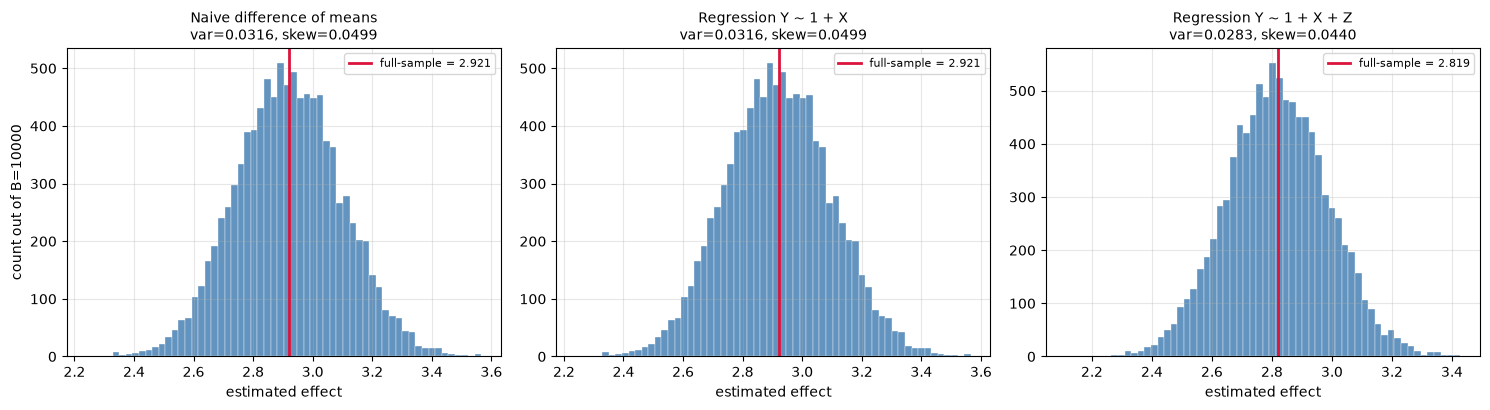

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
panels = [
    (boot_naive,  "Naive difference of means", tau_naive),
    (boot_reg_x,  "Regression Y ~ 1 + X",      tau_reg_x),
    (boot_reg_xz, "Regression Y ~ 1 + X + Z",  tau_reg_xz),
]

for ax, (vals, title, point) in zip(axes, panels):
    ax.hist(vals, bins=60, color="steelblue", alpha=0.85, edgecolor="white", linewidth=0.3)
    ax.axvline(point, color="crimson", lw=2, label=f"full-sample = {point:.3f}")
    ax.set_title(f"{title}\nvar={vals.var(ddof=1):.4f}, skew={stats.skew(vals):.4f}", fontsize=10)
    ax.set_xlabel("estimated effect")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axes[0].set_ylabel(f"count out of B={B}")
plt.tight_layout()
plt.show()

## 7. Sanity check - the other column convention

If the file actually means `Z` as the outcome and `Y` as the confounder, these are the numbers.
Compare against the multiple-choice options to see which convention the question intends.

In [72]:
def run_all(x, y, z, label):
    out = {"naive effect": naive_effect(x, y),
           "reg effect (with Z)": reg_effect(x, y, z),
           "reg effect (no Z)": reg_effect(x, y)}
    bn = np.empty(B); bz = np.empty(B); bx = np.empty(B)
    for b in range(B):
        idx = boot_idx[b]
        xb, yb, zb = x[idx], y[idx], z[idx]
        bn[b] = naive_effect(xb, yb)
        bz[b] = reg_effect(xb, yb, zb)
        bx[b] = reg_effect(xb, yb)
    out["boot var of naive"] = bn.var(ddof=1)
    out["boot skew of naive"] = stats.skew(bn)
    out["boot var of reg (with Z)"] = bz.var(ddof=1)
    out["boot skew of reg (with Z)"] = stats.skew(bz)
    out["boot var of reg (no Z)"] = bx.var(ddof=1)
    out["boot skew of reg (no Z)"] = stats.skew(bx)
    return pd.Series(out, name=label)

both = pd.concat([
    run_all(x, y, z, f"outcome={OUTCOME}, confounder={CONFOUND}"),
    run_all(x, z, y, f"outcome={CONFOUND}, confounder={OUTCOME}"),
], axis=1)
both

,"outcome=Y, confounder=Z","outcome=Z, confounder=Y"
naive effect,2.920717,0.048016
reg effect (with Z),2.818696,-0.068984
reg effect (no Z),2.920717,0.048016
boot var of naive,0.031618,0.000615
boot skew of naive,0.049897,0.003997
boot var of reg (with Z),0.028302,0.000622
boot skew of reg (with Z),0.043981,-0.004228
boot var of reg (no Z),0.031618,0.000615
boot skew of reg (no Z),0.049897,0.003997


## 8. Answers

In [73]:
print("Q3  mean effect, treated minus untreated (no adjustment)")
print(f"      {tau_naive:.6f}\n")

print("Q4  bootstrap variance of that naive effect")
print(f"      {var_naive:.6f}        (std. error {np.sqrt(var_naive):.6f})\n")

print("Q5  skewness of the bootstrapped regression effect (intercept included)")
print(f"      Y ~ 1 + X + Z : {stats.skew(boot_reg_xz):.6f}")
print(f"      Y ~ 1 + X     : {stats.skew(boot_reg_x):.6f}")
print("      (skew near 0 means the bootstrap distribution is close to symmetric;")
print("       positive = long right tail, negative = long left tail)")

Q3  mean effect, treated minus untreated (no adjustment)
      2.920717

Q4  bootstrap variance of that naive effect
      0.031618        (std. error 0.177816)

Q5  skewness of the bootstrapped regression effect (intercept included)
      Y ~ 1 + X + Z : 0.043981
      Y ~ 1 + X     : 0.049897
      (skew near 0 means the bootstrap distribution is close to symmetric;
       positive = long right tail, negative = long left tail)
